# <u> NOTEBOOK PERMETTANT DE REPONDRE AUX DEMANDES DE JULIE </U>

### <U> Import des librairies utiles pour ce projet </U>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from scipy import stats
import statsmodels.api as sm

H1 ELEMENT A SUPPRIMER LORS DU RENDU DU NOTEBOOK

scipy.stats contient :
- tests de normalité : shapiro, normaltest, anderson
- tests paramétriques : ttest_ind, ttest_rel
- tests non paramétriques : mannwhitneyu, kruskal, wilcoxon
- corrélations : pearsonr, spearmanr, kendalltau
- distributions : norm, binom, poisson, etc.
Donc importer tout le module est logique, importer toutes les fonctions l’est beaucoup moins.


### <u> Chargement du dataset selon les csv remis lors de la mission </u>

In [17]:
df_lapage=pd.read_csv(r'..\..\projet9_Lapage\data\processed\df_lapage.csv',sep=';', encoding='utf-8', low_memory=False)

In [18]:
# Ajout de l'âge des clients au df_lapage

df_lapage['date'] = pd.to_datetime(df_lapage['date'])
df_lapage['birth'] = pd.to_datetime(df_lapage['birth'], format='%Y')
df_lapage['age'] = (df_lapage['date'] - df_lapage['birth']).dt.days // 365

In [19]:
df_lapage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
 4   price       687534 non-null  float64       
 5   categ       687534 non-null  int64         
 6   sex         687534 non-null  object        
 7   birth       687534 non-null  datetime64[ns]
 8   age         687534 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(4)
memory usage: 47.2+ MB


# <u> TRAITEMENT DES DEMANDES DE JULIE </U>

## <u> Le lien entre le genre d’un client et les catégories des livres achetés </u>

<Axes: xlabel='sex'>

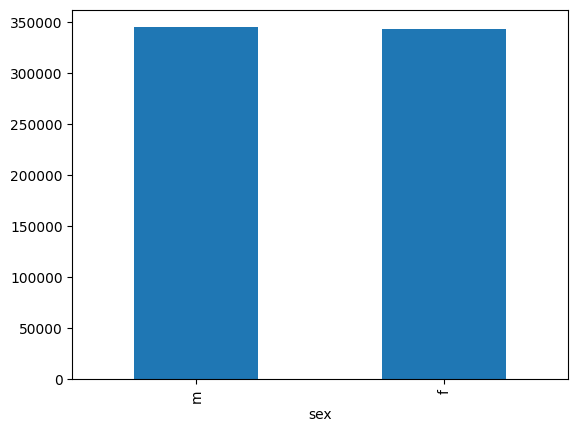

In [28]:
# Etapes préalables

##### REPARTITION DES CLIENTS PAR GENRE
df_lapage['sex'].value_counts(normalize=True)
df_lapage['sex'].value_counts().plot(kind='bar')

<Axes: xlabel='categ'>

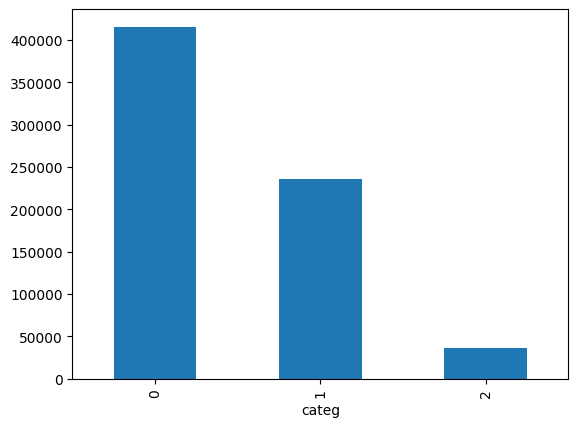

In [29]:
##### REPARTITION DES CATEGORIES DE LIVRES
df_lapage['categ'].value_counts(normalize=True)
df_lapage['categ'].value_counts().plot(kind='bar')


In [21]:
# Quali - quali

## <u> Le lien entre l'âge des clients et le montant total des achats </u> 

In [22]:
# Avant de réaliser quelque test que ce soit, il nous faut d'abord emettre deux types d'hypothèses
# Hypothèse nulle (H0) : elle postule que les données suivent une distribution normale.
# Hypothèse alternative (H1) : elle indique que les données ne suivent pas une distribution normale. Elle est retenue si les données fournissent des preuves suffisantes pour rejeter l'hypothèse nulle. 

# Genre des clients
age = df_lapage['age'].dropna()

# Effectuer le test de Shapiro-Wilk
stat, p_value = stats.shapiro(age)

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat:.4f}")
print(f"Valeur p : {p_value:.4f}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

Statistique du test de Shapiro-Wilk : 0.9748
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)


c:\Users\julie\OneDrive\projet9_Lapage\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 687534.
  res = hypotest_fun_out(*samples, **kwds)


Le test de Shapiro n'est pas adapté aux grands échantillons 

In [25]:
from scipy.stats import normaltest

stat, p_value = normaltest(df_lapage["age"].dropna())

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat:.4f}")
print(f"Valeur p : {p_value:.4f}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

Statistique du test de Shapiro-Wilk : 35014.1722
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)


<Axes: ylabel='Frequency'>

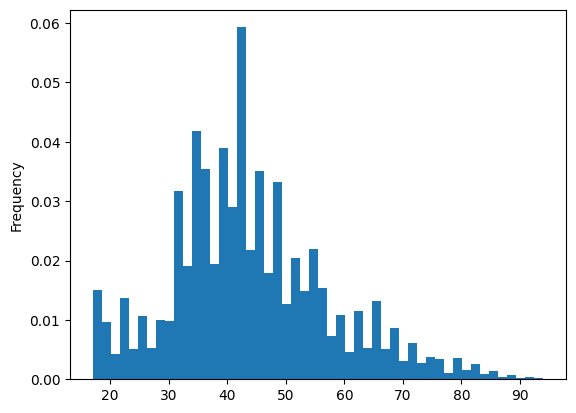

In [ ]:
df_lapage["age"].plot(kind="hist", bins=50, density=True)

On constate par le test D'AGOSTINO K² et l'histogramme que la distribution des valeurs age ne suivent pas une loi normale. P_value < 0.05

In [ ]:
# Quanti - quanti



## <u> Le lien entre l'âge des clients et la fréquence d’achat </u> 

In [ ]:
# Quanti - quanti



## <u> Le lien entre l'âge des clients et la taille du panier moyen </u> 

In [ ]:
# Quanti - quanti




## <u> Le lien entre l'âge des clients et la  catégorie  des livres achetés </u> 

<Axes: xlabel='categ'>

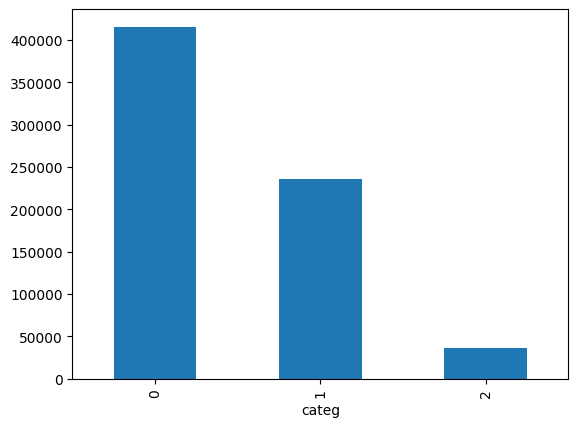

In [26]:
df_lapage['categ'].value_counts(normalize=True)
df_lapage['categ'].value_counts().plot(kind='bar')

In [ ]:
# Quanti - quali


